based on results generated by parallel_simulation_example.py and chunking_factor_simulation.py

In [1]:
import multiprocessing as mp
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from bettercode.parallel_base import run_parallel, run_serial
from bettercode.utils import save_fig

IMAGE_DIR = Path("../../latex/figures")
CHAPTER = 10



In [2]:


df = pd.read_csv('../../src/bettercode/data/parallel/mandelbrot_scaling_cf1.csv')

# Create plot with two panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ncores_list = df.n_cores.unique()

# Panel 1: Speedup vs Log Complexity
for n_cores in ncores_list:
    df_subset = df[df["n_cores"] == n_cores]
    ax1.plot(
        df_subset["log_complexity"],
        df_subset["speedup"],
        "o-",
        linewidth=2,
        markersize=8,
        label=f"{n_cores} cores",
    )

# Add line at 1 to show serial performance baseline
ax1.axhline(
    y=1,
    color="red",
    linestyle=":",
    alpha=0.7,
    linewidth=1.5,
    label="Serial baseline",
)

# Add theoretical maximum lines
for n_cores in ncores_list:
    ax1.axhline(y=n_cores, color="gray", linestyle="--", alpha=0.3, linewidth=0.8)

ax1.set_xlabel("Log₂(Computational Complexity)", fontsize=12)
ax1.set_ylabel("Speedup (Serial Time / Parallel Time)", fontsize=12)
ax1.set_title("Parallel Processing Speedup", fontsize=14, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend(title="Cores Used")

# Panel 2: Efficiency vs Log Image Size (using log_complexity as proxy)
for n_cores in ncores_list:
    df_subset = df[df["n_cores"] == n_cores]
    ax2.plot(
        df_subset["log_complexity"],
        df_subset["efficiency_percent"],
        "o-",
        linewidth=2,
        markersize=8,
        label=f"{n_cores} cores",
    )

# Add 100% efficiency line as reference
ax2.axhline(
    y=100,
    color="red",
    linestyle=":",
    alpha=0.7,
    linewidth=1.5,
    label="100% efficiency",
)

ax2.set_xlabel("Log₂(Image Size)", fontsize=12)
ax2.set_ylabel("Parallel Efficiency (%)", fontsize=12)
ax2.set_title("Parallel Processing Efficiency", fontsize=14, fontweight="bold")
ax2.grid(True, alpha=0.3)
ax2.legend(title="Cores Used")

plt.tight_layout()

# Save figure
save_fig(fig, "scaling", CHAPTER, basedir=IMAGE_DIR)

plt.close()



'../../latex/figures/10/chunking.pdf'

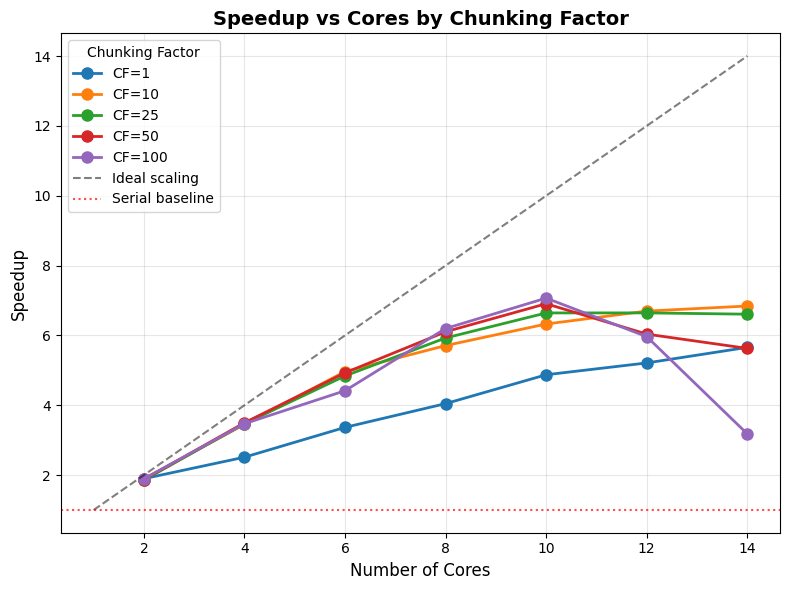

In [3]:
df = pd.read_csv('../../src/bettercode/data/parallel/chunking_factor_simulation.csv')



# Figure 1: Speedup vs Number of Cores for each chunking factor
fig1, ax1 = plt.subplots(figsize=(8, 6))

for cf in df.chunking_factor.unique():
    df_cf = df[(df['chunking_factor'] == cf) & (df['n_cores'] > 1)]
    ax1.plot(df_cf['n_cores'], df_cf['speedup'],
                'o-', linewidth=2, markersize=8, label=f'CF={cf}')

# Add ideal scaling line
ax1.plot(ncores_list, ncores_list, 'k--', alpha=0.5, label='Ideal scaling')
ax1.axhline(y=1, color='red', linestyle=':', alpha=0.7, label='Serial baseline')

ax1.set_xlabel('Number of Cores', fontsize=12)
ax1.set_ylabel('Speedup', fontsize=12)
ax1.set_title('Speedup vs Cores by Chunking Factor', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(title='Chunking Factor')

plt.tight_layout()
save_fig(fig1, "chunking", CHAPTER, basedir=IMAGE_DIR)




In [4]:
df

,n_cores,chunking_factor,n_chunks,grid_width,grid_height,max_iterations,complexity,serial_time,parallel_time,speedup,efficiency_percent
0,1,1,1,4096,4096,100,1677721600,25.342718,25.342718,1.000000,100.000000
1,2,1,2,4096,4096,100,1677721600,25.342718,13.354720,1.897660,94.882999
2,4,1,4,4096,4096,100,1677721600,25.342718,10.085217,2.512858,62.821449
3,6,1,6,4096,4096,100,1677721600,25.342718,7.527483,3.366692,56.111536
4,8,1,8,4096,4096,100,1677721600,25.342718,6.262442,4.046779,50.584737
5,10,1,10,4096,4096,100,1677721600,25.342718,5.199876,4.873716,48.737157
6,12,1,12,4096,4096,100,1677721600,25.342718,4.862628,5.211733,43.431105
7,14,1,14,4096,4096,100,1677721600,25.342718,4.479478,5.657516,40.410831
8,2,10,20,4096,4096,100,1677721600,25.342718,13.403704,1.890725,94.536247
9,4,10,40,4096,4096,100,1677721600,25.342718,7.340965,3.452232,86.305809
